In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import os


plot_dir = "/home/bbc8731/BioMedFormer/data/plot/random_split/"
data_dir_biomedformer = "/home/bbc8731/BioMedFormer/data/result/biomedformer_atr_transductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250705_122538/"
data_dir_GNN = "/home/bbc8731/BioMedFormer/data/"
# queried_edge_types = ['indication', 'contraindication', 'off-label use', 'drug_protein', 'drug_effect']


In [2]:
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "LP_test.csv"))

RGCN_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_drug_gene/auprc_('drug', 'drug_protein', 'gene').csv"))
RGCN_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_drug_ADR/auprc_('drug', 'drug_effect', 'phenotype').csv"))
RGCN_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_RGCN_offlabel/auprc_('disease', 'offlabel', 'drug').csv"))

HAN_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_drug_gene/auprc_('drug', 'drug_protein', 'gene').csv"))
HAN_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_drug_ADR/auprc_('drug', 'drug_effect', 'phenotype').csv"))
HAN_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HAN_offlabel/auprc_('disease', 'offlabel', 'drug').csv"))

HGT_drugprotein = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_drug_gene/auprc_('drug', 'drug_protein', 'gene').csv"))
HGT_drugADR = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_drug_ADR/auprc_('drug', 'drug_effect', 'phenotype').csv"))
HGT_drugofflabel = pd.read_csv(os.path.join(data_dir_GNN, "ray_tune_HGT_offlabel/auprc_('disease', 'offlabel', 'drug').csv"))


In [4]:
seeds = [42, 43, 44, 45, 46]

# Group by seed
grouped = Lp_test.groupby('seed')
# Extract the first and second rows per seed
indication_auprcs = grouped.nth(0)['auprc']
contraindication_auprcs = grouped.nth(1)['auprc']
offlabel_auprcs = grouped.nth(2)['auprc']
drugprotein_auprcs = grouped.nth(3)['auprc']
drugeffect_auprcs = grouped.nth(4)['auprc']

# Compute their means
mean_indication_auprcs = indication_auprcs.mean()
mean_contraindication_auprcs = contraindication_auprcs.mean()
mean_offlabel_auprcs = offlabel_auprcs.mean()
mean_drugprotein_auprcs = drugprotein_auprcs.mean()
mean_drugeffect_auprcs = drugeffect_auprcs.mean()


std_indication_auprcs = indication_auprcs.std()
std_contraindication_auprcs = contraindication_auprcs.std()
std_offlabel_auprcs = offlabel_auprcs.std()
std_drugprotein_auprcs = drugprotein_auprcs.std()
std_drugeffect_auprcs = drugeffect_auprcs.std()


print(f"Mean AUPRC of first entries per seed: {mean_indication_auprcs:.6f}")
print(f"Mean AUPRC of second entries per seed: {mean_contraindication_auprcs:.6f}")
print(f"Mean AUPRC of first entries per seed: {mean_offlabel_auprcs:.6f}")
print(f"Mean AUPRC of second entries per seed: {mean_drugprotein_auprcs:.6f}")
print(f"Mean AUPRC of first entries per seed: {mean_drugeffect_auprcs:.6f}")

Mean AUPRC of first entries per seed: 0.969834
Mean AUPRC of second entries per seed: 0.934408
Mean AUPRC of first entries per seed: 0.969089
Mean AUPRC of second entries per seed: 0.952186
Mean AUPRC of first entries per seed: 0.925812


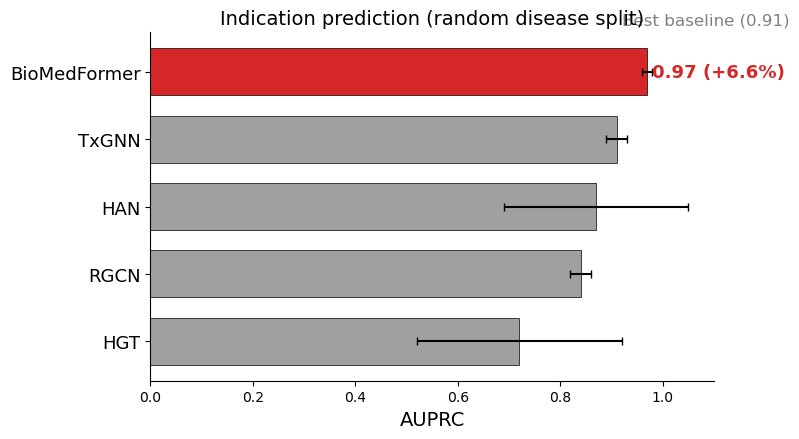

In [11]:
# AUPRC values for indication–random split
# methods = ["JS", "DSD", "KL", "Proximity", "HGT", "BioBERT", "RGCN", "HAN", "TxGNN", "BioMedFormer"]
# means = [0.49, 0.49, 0.50, 0.53, 0.72, 0.81, 0.84, 0.87, 0.91, round(mean_indication_auprcs, 2)]
# stds = [0.01, 0.02, 0.01, 0.04, 0.2, 0.02, 0.02, 0.18, 0.02, round(std_indication_auprcs, 2)]

methods = ["HGT", "RGCN", "HAN", "TxGNN", "BioMedFormer"]
means = [0.72, 0.84, 0.87, 0.91, round(mean_indication_auprcs, 2)]
stds = [0.2, 0.02, 0.18, 0.02, round(std_indication_auprcs, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


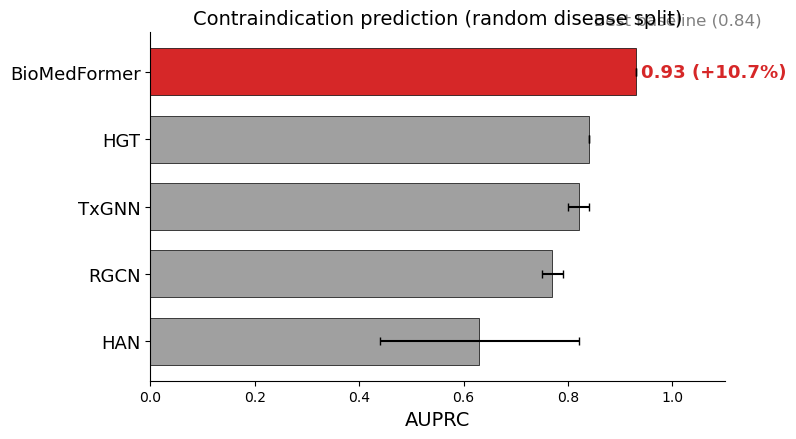

In [12]:
# AUPRC values for contraindication–random split
# methods = ["KL", "Proximity", "JS", "DSD", "BioBERT", "HAN", "RGCN", "HGT", "TxGNN", "BioMedFormer"]
# means = [0.49, 0.49, 0.50, 0.56, 0.58, 0.63, 0.77, 0.84, 0.82, round(mean_contraindication_auprcs, 2)]
# stds = [0.01, 0.01, 0.01, 0.00,  0.01, 0.19, 0.02, 0.00, 0.02, round(std_contraindication_auprcs, 2)]


methods = ["HAN", "RGCN", "HGT", "TxGNN", "BioMedFormer"]
means = [0.63, 0.77, 0.84, 0.82, round(mean_contraindication_auprcs, 2)]
stds = [0.19, 0.02, 0.00, 0.02, round(std_contraindication_auprcs, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding
fig, ax = plt.subplots(figsize=(8, fig_height))

y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Contraindication prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_contraindication_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()


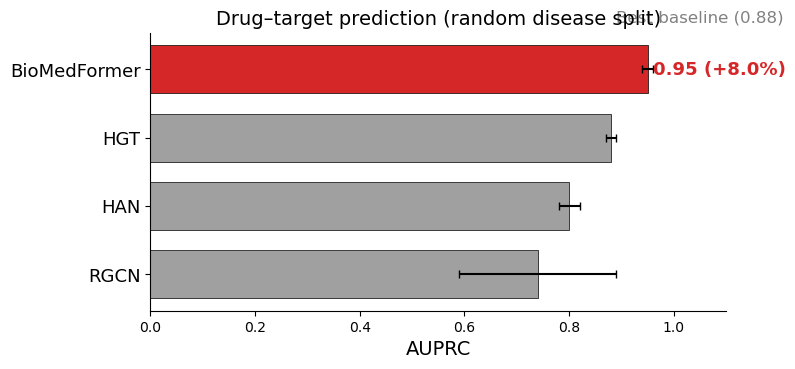

In [5]:
# AUPRC values for drug-protein–random split
methods = ["RGCN", "HAN", "HGT", "BioMedFormer"]
means = [round(RGCN_drugprotein['auprc'].mean(),2), 
         round(HAN_drugprotein['auprc'].mean(),2), 
         round(HGT_drugprotein['auprc'].mean(),2), 
         round(mean_drugprotein_auprcs, 2)]

stds = [round(RGCN_drugprotein['auprc'].std(),2), 
        round(HAN_drugprotein['auprc'].std(),2), 
        round(HGT_drugprotein['auprc'].std(),2),
        round(std_drugprotein_auprcs, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug–target prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_drugprotein_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()

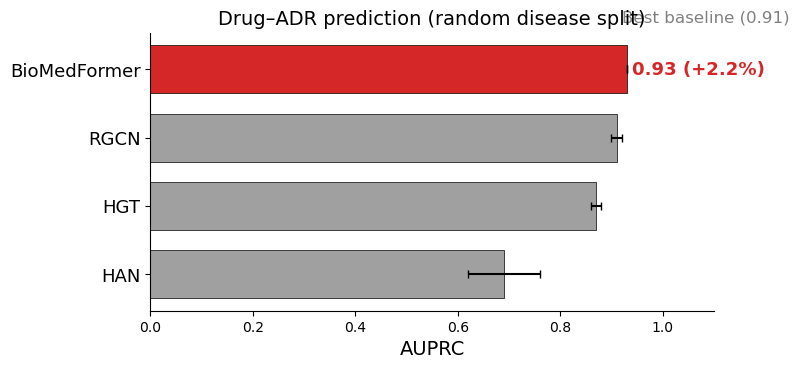

In [6]:
# AUPRC values for drug-ADR–random split
methods = ["RGCN", "HAN", "HGT", "BioMedFormer"]
means = [round(RGCN_drugADR['auprc'].mean(),2), 
         round(HAN_drugADR['auprc'].mean(),2), 
         round(HGT_drugADR['auprc'].mean(),2), 
         round(mean_drugeffect_auprcs, 2)]

stds = [round(RGCN_drugADR['auprc'].std(),2), 
        round(HAN_drugADR['auprc'].std(),2), 
        round(HGT_drugADR['auprc'].std(),2),
        round(std_drugeffect_auprcs, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug–ADR prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_drugADR_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()

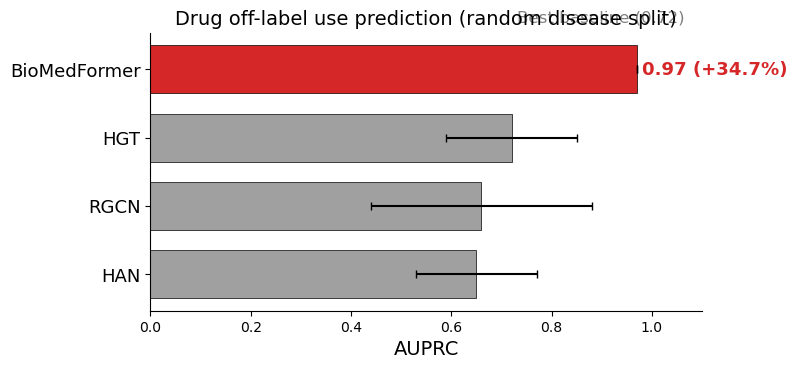

In [10]:
# AUPRC values for drug-offlabel–random split
methods = ["RGCN", "HAN", "HGT", "BioMedFormer"]
means = [round(RGCN_drugofflabel['auprc'].mean(),2), 
         round(HAN_drugofflabel['auprc'].mean(),2), 
         round(HGT_drugofflabel['auprc'].mean(),2), 
         round(mean_offlabel_auprcs, 2)]

stds = [round(RGCN_drugofflabel['auprc'].std(),2), 
        round(HAN_drugofflabel['auprc'].std(),2), 
        round(HGT_drugofflabel['auprc'].std(),2),
        round(std_offlabel_auprcs, 2)]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Plot

# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)


# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer":
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Drug off-label use prediction (random disease split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_offlabel_random_split.png"), dpi=300, bbox_inches="tight")
plt.show()